# Notebook 07 — Proyecciones Temporales hasta Diciembre 2027

**Proyecto:** Sistema de Predicción y Clasificación de la Desnutrición en niños menores de cinco años  
**Fuente:** SIVIGILA — Evento 113 (Desnutrición aguda) — 2020-2026  
**Destino:** Tablas BigQuery para visualización en Power BI

---
## Proyecciones

| # | Proyección | Métrica | Tabla BigQuery |
|---|---|---|---|
| 1 | Casos totales mensuales | `casos` | `proy_casos_mensual` |
| 2 | Tasa de desnutrición severa | `tasa_severa` | `proy_tasa_severa` |
| 3 | Tasa de desnutrición moderada | `tasa_moderada` | `proy_tasa_moderada` |
| 4 | Z-score promedio mensual | `zscore_pt_media` | `proy_zscore_mensual` |
| 5 | Casos mensuales por departamento | `casos` × `ndep_resi` | `proy_casos_departamento` |

**Columnas de filtro en cada tabla (para Power BI):**  
`anio_mes | fecha | anio | mes | trimestre | semestre | valor | limite_inf_80 | limite_sup_80 | limite_inf_95 | limite_sup_95 | tipo`

**Horizonte:** febrero 2026 → diciembre 2027 (23 meses de proyección)  
**Modelo:** Prophet (Facebook) — captura tendencia + estacionalidad anual

## 1. Importación de librerías

In [29]:
import sys
!{sys.executable} -m pip install pandas-gbq google-cloud-bigquery statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import google.auth
from google.cloud import bigquery
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 2. Carga de datos desde BigQuery

In [30]:
credentials, project_id = google.auth.default(
    scopes=['https://www.googleapis.com/auth/cloud-platform']
)
bq_client  = bigquery.Client(project=project_id, credentials=credentials)
dataset_bq = 'desnutricion'

serie_mensual = bq_client.query(
    f'SELECT * FROM `{project_id}.{dataset_bq}.serie_temporal_mensual` ORDER BY anio_mes'
).to_dataframe()

df_full = bq_client.query(
    f'SELECT anio_mes, ndep_resi, clas_peso FROM `{project_id}.{dataset_bq}.limpio_unificado`'
).to_dataframe()

print(f'Serie mensual   : {serie_mensual.shape[0]} puntos')
print(f'Limpio unificado: {df_full.shape[0]:,} registros')
print(f'Rango temporal  : {serie_mensual["anio_mes"].min()} → {serie_mensual["anio_mes"].max()}')

Serie mensual   : 73 puntos
Limpio unificado: 3,428 registros
Rango temporal  : 2020-01 → 2026-01


## 3. Funciones auxiliares

In [31]:
HORIZONTE_MESES = 23
FECHA_CORTE     = '2027-12'


def preparar_serie(df_serie, col_y):
    df = df_serie[['anio_mes', col_y]].copy()
    df['ds'] = pd.to_datetime(df['anio_mes'] + '-01')
    return df.rename(columns={col_y: 'y'})[['ds', 'y']].dropna().reset_index(drop=True)


def ajustar_sarima(df_train, horizonte=HORIZONTE_MESES):
    model  = SARIMAX(
        df_train['y'].values,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result       = model.fit(disp=False)
    forecast_obj = result.get_forecast(steps=horizonte)

    pred_mean = np.asarray(forecast_obj.predicted_mean)
    ci_95     = np.asarray(forecast_obj.conf_int(alpha=0.05))
    ci_80     = np.asarray(forecast_obj.conf_int(alpha=0.20))

    ultima_fecha = df_train['ds'].max()
    fechas_fut   = pd.date_range(
        start=ultima_fecha + pd.DateOffset(months=1),
        periods=horizonte, freq='MS'
    )

    forecast_df = pd.DataFrame({
        'ds'          : fechas_fut,
        'yhat'        : pred_mean,
        'yhat_lower95': ci_95[:, 0],
        'yhat_upper95': ci_95[:, 1],
        'yhat_lower80': ci_80[:, 0],
        'yhat_upper80': ci_80[:, 1],
    })
    return result, forecast_df


def combinar_historico_proyeccion(df_train, forecast_df):
    hist = df_train.copy()
    hist['anio_mes']      = hist['ds'].dt.to_period('M').astype(str)
    hist['valor']         = hist['y']
    hist['limite_inf_95'] = np.nan
    hist['limite_sup_95'] = np.nan
    hist['limite_inf_80'] = np.nan
    hist['limite_sup_80'] = np.nan
    hist['tipo']          = 'historico'

    proy = forecast_df.copy()
    proy['anio_mes'] = proy['ds'].dt.to_period('M').astype(str)
    proy = proy[proy['anio_mes'] <= FECHA_CORTE]

    proy_out = pd.DataFrame({
        'anio_mes'      : proy['anio_mes'].values,
        'valor'         : proy['yhat'].values,
        'limite_inf_80' : proy['yhat_lower80'].values,
        'limite_sup_80' : proy['yhat_upper80'].values,
        'limite_inf_95' : proy['yhat_lower95'].values,
        'limite_sup_95' : proy['yhat_upper95'].values,
        'tipo'          : 'proyeccion',
    })

    cols = ['anio_mes', 'valor', 'limite_inf_80', 'limite_sup_80',
            'limite_inf_95', 'limite_sup_95', 'tipo']
    return pd.concat([hist[cols], proy_out], ignore_index=True)


def agregar_columnas_filtro(df):
    df = df.copy()
    df['fecha']     = pd.to_datetime(df['anio_mes'] + '-01')
    df['anio']      = df['fecha'].dt.year
    df['mes']       = df['fecha'].dt.month
    df['trimestre'] = df['fecha'].dt.quarter
    df['semestre']  = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
    df['fecha']     = df['fecha'].astype(str)
    return df


def graficar_proyeccion(df, titulo, unidad=''):
    hist = df[df['tipo'] == 'historico'].copy()
    proy = df[df['tipo'] == 'proyeccion'].copy()
    hist['_f'] = pd.to_datetime(hist['fecha'])
    proy['_f'] = pd.to_datetime(proy['fecha'])

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(hist['_f'], hist['valor'], 'o-', color='#2c3e50',
            linewidth=2, markersize=4, label='Histórico', zorder=5)
    ax.plot(proy['_f'], proy['valor'], 's--', color='#185fa5',
            linewidth=2.5, markersize=6, label='Proyección', zorder=5)
    ax.fill_between(proy['_f'], proy['limite_inf_95'], proy['limite_sup_95'],
                    alpha=0.12, color='#185fa5', label='IC 95%')
    ax.fill_between(proy['_f'], proy['limite_inf_80'], proy['limite_sup_80'],
                    alpha=0.22, color='#185fa5', label='IC 80%')
    ax.axvline(pd.to_datetime(hist['_f'].max()), color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(titulo, fontsize=13)
    ax.set_ylabel(unidad)
    ax.legend(fontsize=9, framealpha=0.5)
    plt.tight_layout()
    plt.show()


print('Funciones helper cargadas (modelo: SARIMA).')
print(f'Horizonte: {HORIZONTE_MESES} meses → hasta {FECHA_CORTE}')


Funciones helper cargadas (modelo: SARIMA).
Horizonte: 23 meses → hasta 2027-12


---
## 4. Proyección 1 — Casos totales mensuales

**Pregunta:** ¿Cuántos casos de desnutrición habrá cada mes hasta diciembre 2027?  
**Métrica:** `casos` de `serie_temporal_mensual`

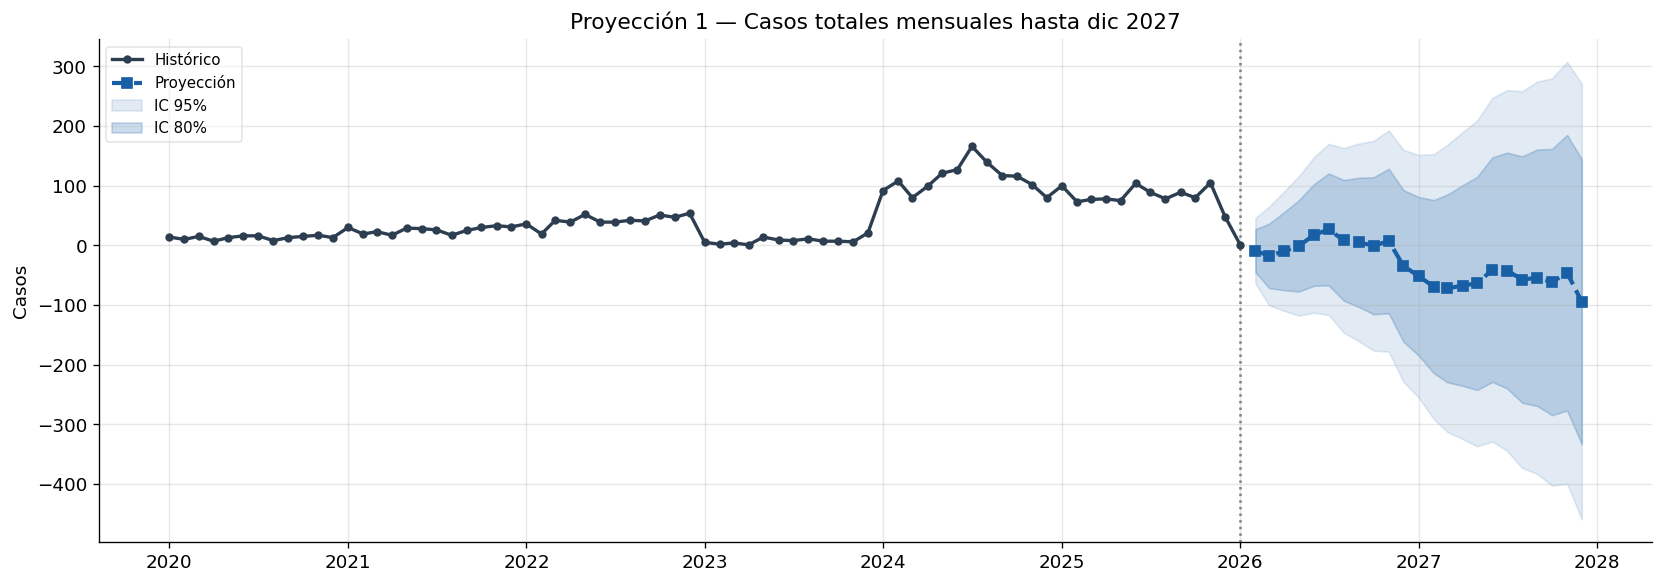

Casos proyectados por año:
anio
2026     -7.0
2027   -720.0


In [32]:
df_train_casos  = preparar_serie(serie_mensual, 'casos')
_, fc_casos     = ajustar_sarima(df_train_casos)
df_casos        = combinar_historico_proyeccion(df_train_casos, fc_casos)
df_casos        = agregar_columnas_filtro(df_casos)
df_casos['metrica'] = 'casos_totales'

graficar_proyeccion(df_casos,
    'Proyección 1 — Casos totales mensuales hasta dic 2027', 'Casos')

proy = df_casos[df_casos['tipo'] == 'proyeccion']
print('Casos proyectados por año:')
print(proy.groupby('anio')['valor'].sum().round(0).to_string())


---
## 5. Proyección 2 — Tasa de desnutrición severa (%)

**Pregunta:** ¿Qué porcentaje de casos serán severos cada mes hasta diciembre 2027?  
**Métrica:** `tasa_severa` de `serie_temporal_mensual`

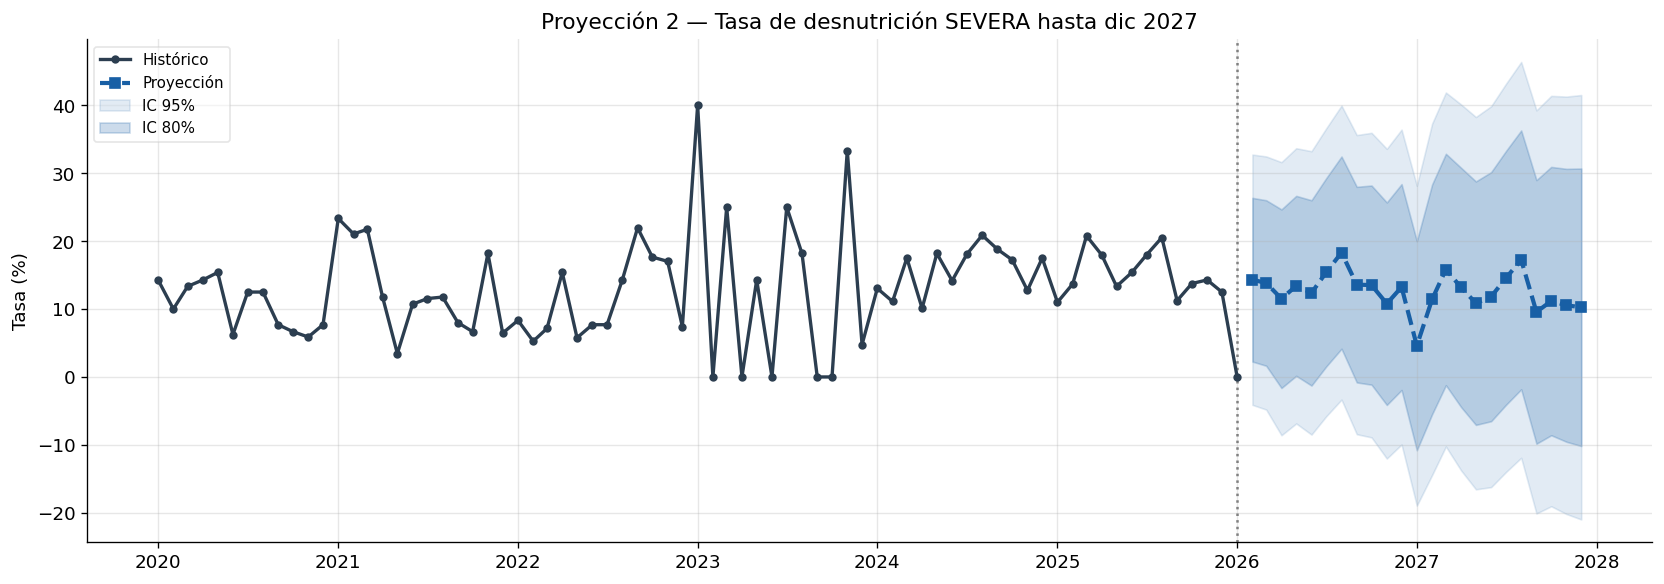

Tasa severa promedio por año:
anio
2026    13.66
2027    11.75


In [33]:
df_train_severa = preparar_serie(serie_mensual, 'tasa_severa')
_, fc_severa    = ajustar_sarima(df_train_severa)
df_severa       = combinar_historico_proyeccion(df_train_severa, fc_severa)
df_severa       = agregar_columnas_filtro(df_severa)
df_severa['metrica'] = 'tasa_severa'

graficar_proyeccion(df_severa,
    'Proyección 2 — Tasa de desnutrición SEVERA hasta dic 2027', 'Tasa (%)')

proy = df_severa[df_severa['tipo'] == 'proyeccion']
print('Tasa severa promedio por año:')
print(proy.groupby('anio')['valor'].mean().round(2).to_string())


---
## 6. Proyección 3 — Tasa de desnutrición moderada (%)

**Pregunta:** ¿Qué porcentaje de casos serán moderados cada mes hasta diciembre 2027?  
**Métrica:** `tasa_moderada` de `serie_temporal_mensual`

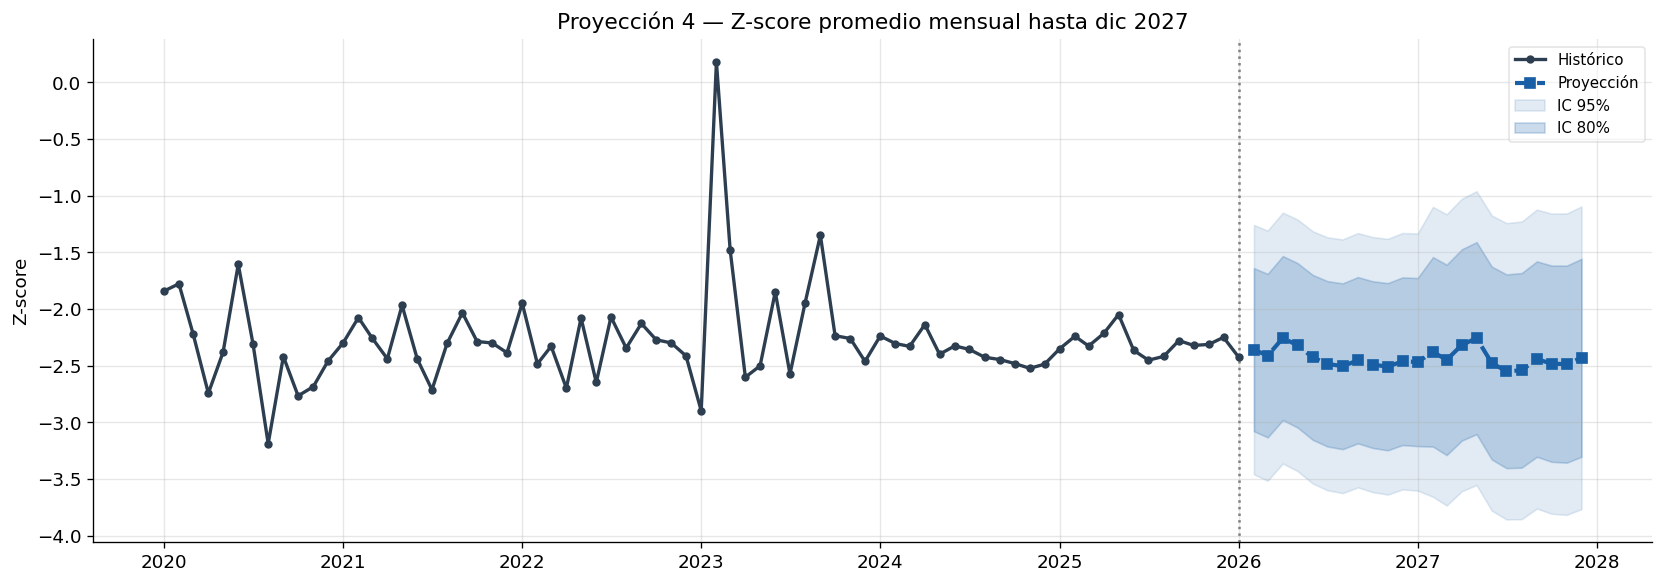

Z-score promedio por año:
anio
2026   -2.425
2027   -2.440

Referencia: -2 = moderada | -3 = severa


In [38]:
df_train_zs = preparar_serie(serie_mensual, 'zscore_pt_media')
_, fc_zs    = ajustar_sarima(df_train_zs)
df_zscore   = combinar_historico_proyeccion(df_train_zs, fc_zs)
df_zscore   = agregar_columnas_filtro(df_zscore)
df_zscore['metrica'] = 'zscore_pt_media'

graficar_proyeccion(df_zscore,
    'Proyección 4 — Z-score promedio mensual hasta dic 2027', 'Z-score')

proy = df_zscore[df_zscore['tipo'] == 'proyeccion']
print('Z-score promedio por año:')
print(proy.groupby('anio')['valor'].mean().round(3).to_string())
print('\nReferencia: -2 = moderada | -3 = severa')


---
## 7. Proyección 4 — Z-score promedio mensual

**Pregunta:** ¿Cómo evoluciona el estado nutricional poblacional hasta diciembre 2027?  
**Métrica:** `zscore_pt_media` de `serie_temporal_mensual`  
**Referencia:** z-score < -2 = desnutrición moderada; < -3 = desnutrición severa

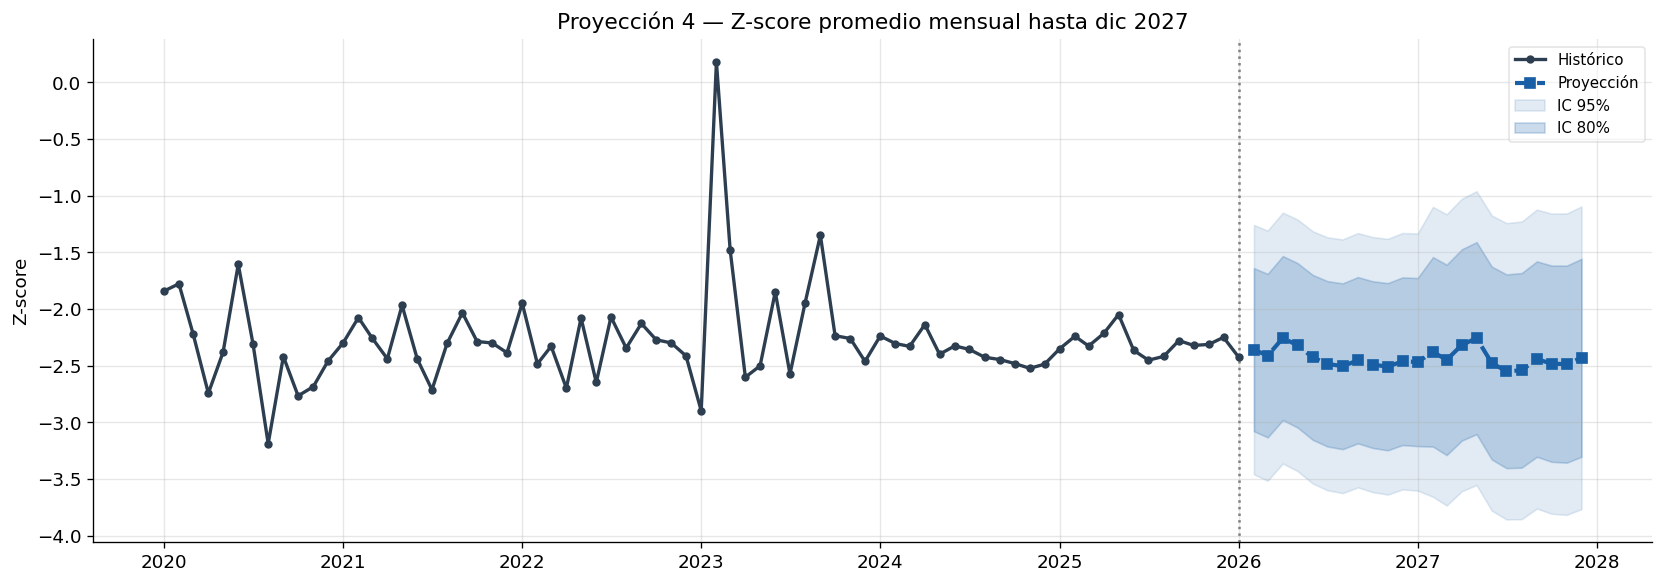

Z-score promedio por año:
anio
2026   -2.425
2027   -2.440

Referencia: -2 = moderada | -3 = severa


In [35]:
df_train_zs = preparar_serie(serie_mensual, 'zscore_pt_media')
_, fc_zs    = ajustar_sarima(df_train_zs)
df_zscore   = combinar_historico_proyeccion(df_train_zs, fc_zs)
df_zscore   = agregar_columnas_filtro(df_zscore)
df_zscore['metrica'] = 'zscore_pt_media'

graficar_proyeccion(df_zscore,
    'Proyección 4 — Z-score promedio mensual hasta dic 2027', 'Z-score')

proy = df_zscore[df_zscore['tipo'] == 'proyeccion']
print('Z-score promedio por año:')
print(proy.groupby('anio')['valor'].mean().round(3).to_string())
print('\nReferencia: -2 = moderada | -3 = severa')


---
## 8. Proyección 5 — Casos mensuales por departamento

**Pregunta:** ¿Cómo evolucionan los casos por departamento hasta diciembre 2027?  
**Fuente:** `limpio_unificado` agregado por `anio_mes` + `ndep_resi`  
**Filtro:** solo departamentos con al menos 24 meses de datos (para que Prophet sea confiable)

Departamentos con >= 24 meses: ['CESAR', 'GUAJIRA', 'MAGDALENA']
  ✓ CESAR
  ✓ GUAJIRA
  ✓ MAGDALENA

Total: 265 filas


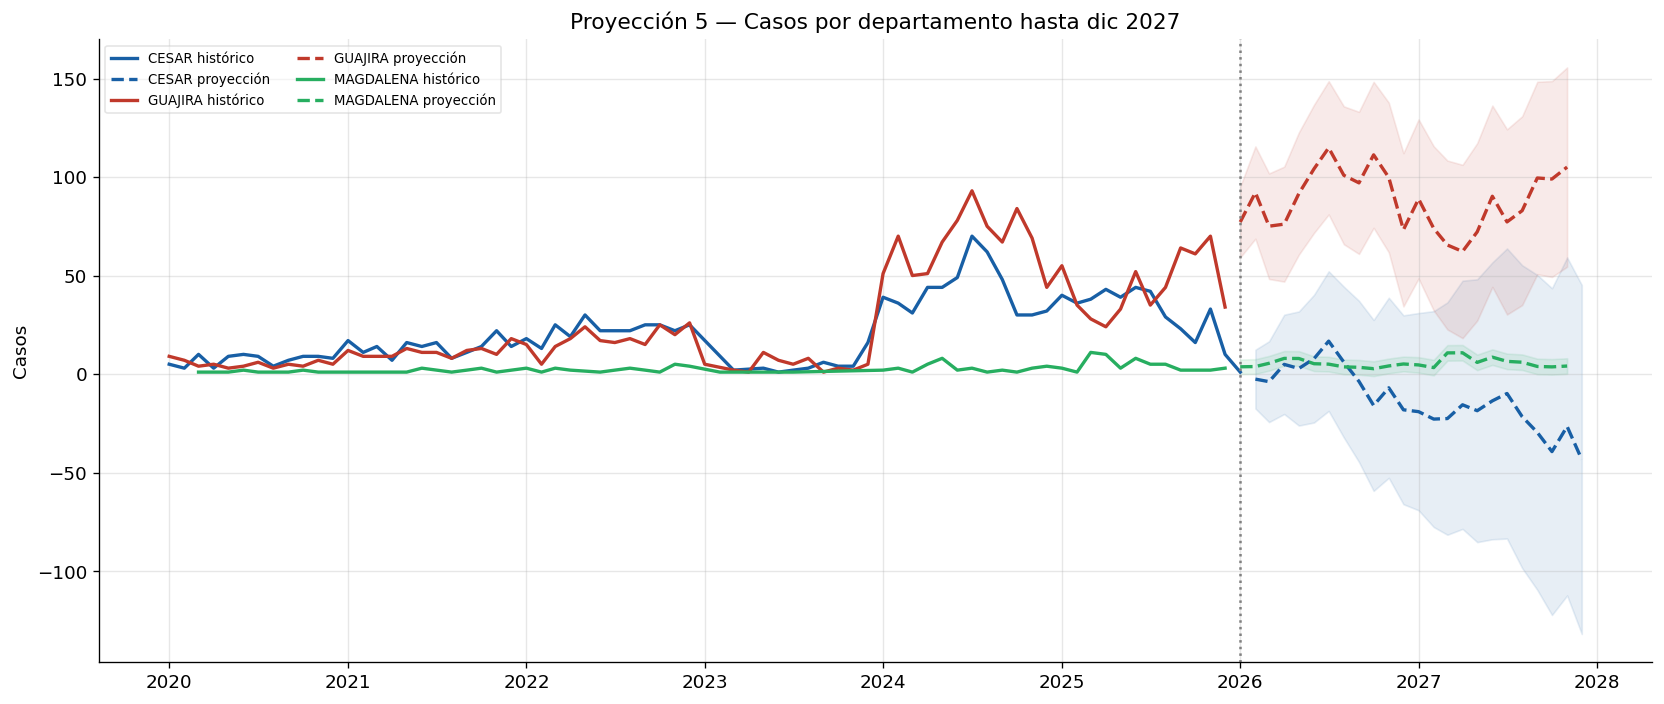

In [36]:
serie_dpto_mensual = (
    df_full[df_full['ndep_resi'].notna()]
    .groupby(['ndep_resi', 'anio_mes'])
    .size()
    .reset_index(name='casos')
    .sort_values(['ndep_resi', 'anio_mes'])
)

meses_por_dpto = serie_dpto_mensual.groupby('ndep_resi')['anio_mes'].nunique()
deptos_ok      = meses_por_dpto[meses_por_dpto >= 24].index.tolist()
print(f'Departamentos con >= 24 meses: {deptos_ok}')

resultados_dpto = []
for dpto in deptos_ok:
    sub      = serie_dpto_mensual[serie_dpto_mensual['ndep_resi'] == dpto].copy()
    df_train = sub.copy()
    df_train['ds'] = pd.to_datetime(df_train['anio_mes'] + '-01')
    df_train = df_train.rename(columns={'casos': 'y'})[['ds', 'y']].reset_index(drop=True)

    _, forecast_df = ajustar_sarima(df_train)
    resultado      = combinar_historico_proyeccion(df_train, forecast_df)
    resultado      = agregar_columnas_filtro(resultado)
    resultado['departamento'] = dpto
    resultados_dpto.append(resultado)
    print(f'  ✓ {dpto}')

df_deptos = pd.concat(resultados_dpto, ignore_index=True)
print(f'\nTotal: {len(df_deptos):,} filas')

colores_dpto = ['#185fa5', '#c0392b', '#27ae60', '#8e44ad', '#e67e22']
fig, ax = plt.subplots(figsize=(14, 6))
for i, dpto in enumerate(deptos_ok):
    sub       = df_deptos[df_deptos['departamento'] == dpto].copy()
    sub['_f'] = pd.to_datetime(sub['fecha'])
    hist  = sub[sub['tipo'] == 'historico']
    proy  = sub[sub['tipo'] == 'proyeccion']
    color = colores_dpto[i % len(colores_dpto)]
    ax.plot(hist['_f'], hist['valor'], '-',  color=color, linewidth=2, label=f'{dpto} histórico')
    ax.plot(proy['_f'], proy['valor'], '--', color=color, linewidth=2, label=f'{dpto} proyección')
    ax.fill_between(proy['_f'], proy['limite_inf_80'], proy['limite_sup_80'], alpha=0.10, color=color)

ax.axvline(pd.Timestamp('2026-01-01'), color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Proyección 5 — Casos por departamento hasta dic 2027', fontsize=13)
ax.set_ylabel('Casos')
ax.legend(fontsize=8, framealpha=0.5, ncol=2)
plt.tight_layout()
plt.show()


---
## 9. Exportación a BigQuery

Se exportan las 5 tablas de proyección. Cada tabla incluye:
- **`anio_mes`** — período en formato `YYYY-MM`
- **`fecha`** — fecha en formato `YYYY-MM-DD` (primer día del mes)
- **`anio`, `mes`, `trimestre`, `semestre`** — columnas de filtro para Power BI
- **`valor`** — valor histórico o proyectado
- **`limite_inf_80`, `limite_sup_80`** — banda de confianza del 80%
- **`limite_inf_95`, `limite_sup_95`** — banda de confianza del 95%
- **`tipo`** — `'historico'` o `'proyeccion'`

In [42]:
df_train_mod = preparar_serie(serie_mensual, 'tasa_moderada')
_, fc_mod    = ajustar_sarima(df_train_mod)
df_moderada  = combinar_historico_proyeccion(df_train_mod, fc_mod)
df_moderada  = agregar_columnas_filtro(df_moderada)
df_moderada['metrica'] = 'tasa_moderada'
print('OK:', df_moderada.shape)


OK: (96, 13)


In [41]:
def exportar_proyeccion(df, tabla):
    df.to_gbq(
        destination_table=f'{dataset_bq}.{tabla}',
        project_id=project_id,
        if_exists='replace',
        credentials=credentials,
    )
    h = (df['tipo'] == 'historico').sum()
    p = (df['tipo'] == 'proyeccion').sum()
    print(f'✅ {dataset_bq}.{tabla} — {h} históricas | {p} proyectadas')

exportar_proyeccion(df_casos,    'proy_casos_mensual')
exportar_proyeccion(df_severa,   'proy_tasa_severa')
exportar_proyeccion(df_moderada, 'proy_tasa_moderada')
exportar_proyeccion(df_zscore,   'proy_zscore_mensual')
exportar_proyeccion(df_deptos,   'proy_casos_departamento')

print(f'\nFiltros en Power BI: anio | mes | trimestre | semestre')


100%|██████████| 1/1 [00:00<00:00, 17331.83it/s]


✅ desnutricion.proy_casos_mensual — 73 históricas | 23 proyectadas


100%|██████████| 1/1 [00:00<00:00, 5660.33it/s]


✅ desnutricion.proy_tasa_severa — 73 históricas | 23 proyectadas


100%|██████████| 1/1 [00:00<00:00, 19691.57it/s]


✅ desnutricion.proy_tasa_moderada — 73 históricas | 23 proyectadas


100%|██████████| 1/1 [00:00<00:00, 19418.07it/s]


✅ desnutricion.proy_zscore_mensual — 73 históricas | 23 proyectadas


100%|██████████| 1/1 [00:00<00:00, 11244.78it/s]

✅ desnutricion.proy_casos_departamento — 196 históricas | 69 proyectadas

Filtros en Power BI: anio | mes | trimestre | semestre
